# Unsupervised Learning

**Prerequisites**

- Pandas
- Sklearn
- Supervised Learning
- Linear Algebra

**Outcomes**

- Understand the principal component analysis algorithm for dimensionality reduction
- Understand the k-means algorithm for clustering
- Understand autoencoder models

> Note: Parts of this notebook were inspired by sections from [Python Data Science Handbook](https://jakevdp.github.io/PythonDataScienceHandbook/) by Jake VanderPlas

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
plt.style.use("seaborn-v0_8")

color_cycle = np.array(plt.rcParams["axes.prop_cycle"].by_key()["color"])

## Overview

ML Families:

| Family | Data | examples | 
| ------ | ---- | -------- |
| Supervised | (X, y) | regression/classification |
| **Unsupervised** | (X,) | clustering/dimensionality reduction/etc | 
| Reinforcement | (s, **a**, R, s', **a'**, R'...) | games/robots/financial trading/"control" |

> Note: also semi-supervised, where some X's have a corresponding y, but not all

### Unsupervised Learning


- Today we will focus on unsupervised learning
- The overarching idea: have computer discover structure in unlabeled data
- Algorithms we will study:
    - Principal Component Analysis (PCA)
    - K-means Clustering

## Principal Component Analysis (PCA)

- PCA, at its heart, is primarily an algorithm for *dimensionality reduction*
- This means it is effective at summarizing key varaition in high dimensional data using fewer dimensions
- However, it can also be used for many tasks:
    - Feature engineering
    - Visualization
    - Noise removal/filtering
- We will focus on dimensionality reduction

### Principal Components

- The PCA algorithm represents the relationship between columns of X using the *principal components* of X
    - *Note*: principal components are sometimes called principal axes
- A principal component is a vector of the same dimensionality as $x$ (a row of $X$) that summarizes the direction of greatest variation in the data

### Graphical Example

- PCA is (perhaps) best understood visually
- We'll first show a graphical example then describe the math behind algorithm
- Consider the following dataset:

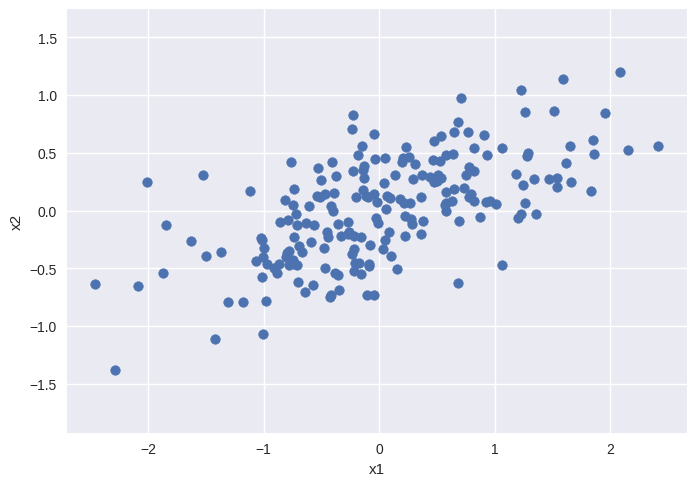

In [8]:
rng = np.random.RandomState(1)
fig, ax = plt.subplots()
X = np.dot(rng.rand(4, 4), rng.randn(4, 200)).T
ax.scatter(X[:, 0], X[:, 1])
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.axis('equal');

- Clear linear relationship between x1 and x2
- In supervised learning...
    - we might build a model $f(x1;\theta)$ such that $x2 \approx f(x1;\theta)$
    - In words: we may try to **predict** x2 given x1
- In unsupervised learning we instead want to learn the relationship between x1 and x2

In [9]:
from sklearn import decomposition

pca = decomposition.PCA(n_components=2)
Xhat = pca.fit_transform(X)

- When fit is called, the PCA algorithm learns two things:
    1. `pca.components_`: matrix whose columns are principal components
    2. `pca.explained_variance_` (or `pca.explained_variance_ratio_`): variance explained by the principal components

In [10]:
print("EVR:", pca.explained_variance_ratio_)
print("PCs:\n", pca.components_)

EVR: [0.90914162 0.07159175]
PCs:
 [[ 0.46551125  0.20831427  0.58461456  0.63097564]
 [-0.50069297  0.4712601   0.62664449 -0.36679306]]


- This tells us that the direction of highest variance is -0.94 x1 and -0.32 x2
    - In other words, 3 times more variance is explained by x1 than x2
- The explained variance ratio tells us that 97% of the variance is explained by the first principal component
- Let's plot these components alongside the data

ValueError: too many values to unpack (expected 2)

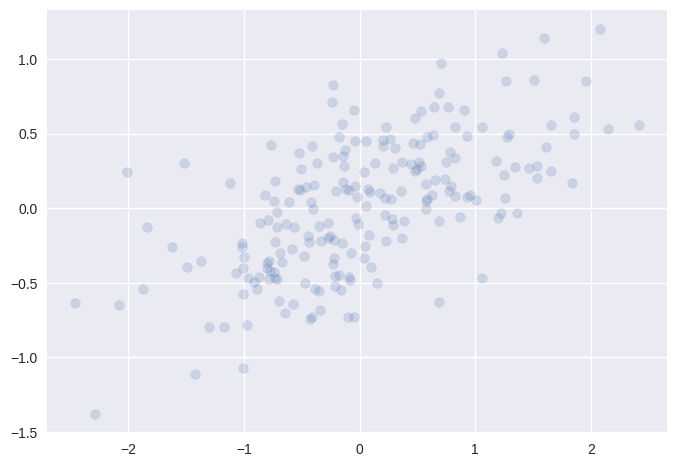

In [11]:
def draw_vector(v0, v1, ax=None):
    ax = ax or plt.gca()
    arrowprops=dict(arrowstyle='->',
                    linewidth=2, color="black",
                    shrinkA=0, shrinkB=0)
    ax.annotate('', v1, v0, arrowprops=arrowprops)

# plot data
plt.scatter(X[:, 0], X[:, 1], alpha=0.2)
for length, vector in zip(pca.explained_variance_, pca.components_):
    v = vector * 3 * np.sqrt(length)
    draw_vector(pca.mean_, pca.mean_ + v)
plt.axis('equal');

### Computing Principal Components

- The most intuitive algorithm for doing PCA is done iteratively
- Before iterating set $i=1$, $\tilde{X}_1 = X$, and choose the number of components K
- Then, on iteration $i$:
    1. Find a unit vector $w_i$ that maximizes the variance of a projection of $X$ onto $w_i$
        1. Mathematically can be done by choosing $w_i$ to maximize $\|\tilde{X}_i w_i\|$ (see below for $\tilde{X}_i$)
        1. Because $w_i$ must have norm 1, this is equivalent to $$w_i = \text{argmax}_w \frac{w^TX^TXw}{w^Tw}$$
    1. After choosing $w_i$, compute $\tilde{X}_{i+1}$: $$\tilde{X}_{i+1} = X - \sum_{s=1}^{i} X w_s w_s^T$$
    1. If $i< K$ continue to next iteration

Let's implement this algorithm below:

In [12]:
from scipy.optimize import minimize

def pca_iterative(X, K):
    vectors = []
    Xtilde = X

    fig, ax = plt.subplots(K, 1)
    for i in range(K):
        print(np.var(Xtilde))
        ax[i].scatter(Xtilde[:, 0], Xtilde[:, 1])
        xhat = Xtilde.T @ Xtilde
        def obj(w):
            return - w@xhat@w / (w@w)
        
        w = minimize(obj, 0.1*np.ones(X.shape[1])).x  # find w
        w /= np.linalg.norm(w)                        # make unit vector
        vectors.append(w)                             # store w_i
        Xtilde = Xtilde - X @ np.outer(w, w)          # update Xtilde
    
    return np.column_stack(vectors)

0.8935487829389845
0.08153201062018875
Iterative PCs:
 [[ 0.46563054 -0.49827261]
 [ 0.20839361  0.4707676 ]
 [ 0.58487102  0.62735362]
 [ 0.63062366 -0.36949925]]
pca.components_:
 [[ 0.46551125  0.20831427  0.58461456  0.63097564]
 [-0.50069297  0.4712601   0.62664449 -0.36679306]]


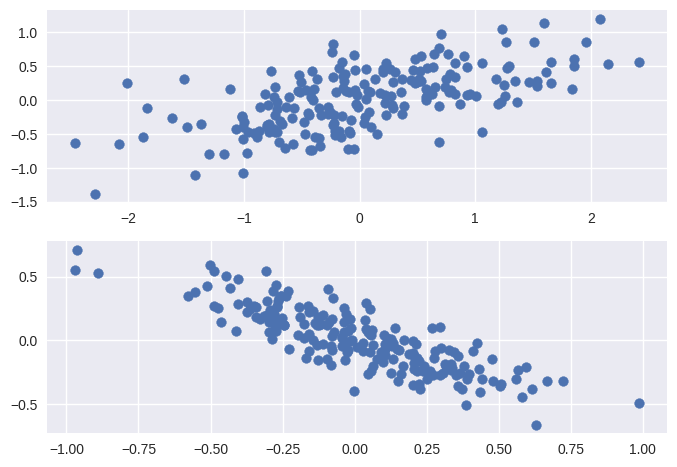

In [13]:
print("Iterative PCs:\n", pca_iterative(X, 2))
print("pca.components_:\n", pca.components_)

In [17]:
pca = decomposition.PCA(n_components=2)
Xhat = pca.fit_transform(X)

In [18]:
pca.explained_variance_ratio_

array([0.90914162, 0.07159175])

In [19]:
pca.explained_variance_

array([3.26454421, 0.25707152])

Note: a projection on $[0.944, 0.328]$ will be the same as one on $[-0.944, -0.328]$, so these principal components are equivalent

### Comments

- The algorithm we implemented above was descriptive, but quite inefficient
- On each iteration we used a non-linear minimizer to find $w_i$
- Using some linear algebra tricks, we could have computed the principal components much more succinctly...

### PCA via eigen decomposition

- For a matrix $X$ whose columns have mean 0, the matrix $X^TX$ is the covariance matrix of $X$
- Principal components end up being eigenvectors of covariance matrix
    - Explained variance is associated eigenvalue

In [20]:
cov = X.T@X
vals, vecs = np.linalg.eig(cov)

In [21]:
vals / vals.sum()

array([0.90878832, 0.07166859, 0.01859185, 0.00095124])

In [22]:
print("vecs:\n", vecs)
pca.components_

vecs:
 [[ 0.46563056  0.49827262  0.69289658 -0.23410875]
 [ 0.20839372 -0.4707676  -0.08957322 -0.85259988]
 [ 0.584871   -0.6273536   0.21578063  0.46668201]
 [ 0.63062362  0.36949928 -0.68213613  0.02178143]]


array([[ 0.46551125,  0.20831427,  0.58461456,  0.63097564],
       [-0.50069297,  0.4712601 ,  0.62664449, -0.36679306]])

- Recall that eigenvalues are only unique up to a scalar multiple
- Multiplying the first column of `vecs` by `-1` gives the components from PCA

- Also, if we divide `vals` by its sum, we get the explained variance ratio:

In [23]:
print("vals / vals.sum():", vals/vals.sum())
pca.explained_variance_ratio_

vals / vals.sum(): [0.90878832 0.07166859 0.01859185 0.00095124]


array([0.90914162, 0.07159175])

### PCA via SVD

- By more linear algebra magic (trust us!), we can also do PCA via the singular value decomposition
- Recall that the SVD of a matrix $X$ is $$X = U \Sigma W^T,$$
    - $U$: n by n matrix whose columns are orthogonal unit vectors (left eigenvectors of $X$)
    - $\Sigma$: diagonal matrix of singular values (eigenvalues)
    - $W$: d by d matrix of orthogonal unit vectors (right eigenvectors of $X$)
- $W$ is our matrix of principal components
- The explained variance is related to the diagonal entries of $\Sigma$

In [24]:
_, _, WT = np.linalg.svd(X)

print("WT:\n", WT)
pca.components_

WT:
 [[-0.46563056 -0.20839372 -0.584871   -0.63062362]
 [-0.49827262  0.4707676   0.6273536  -0.36949928]
 [ 0.69289658 -0.08957322  0.21578063 -0.68213613]
 [-0.23410875 -0.85259988  0.46668201  0.02178143]]


array([[ 0.46551125,  0.20831427,  0.58461456,  0.63097564],
       [-0.50069297,  0.4712601 ,  0.62664449, -0.36679306]])

### Digits

In [25]:
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA

In [26]:
digits = load_digits()

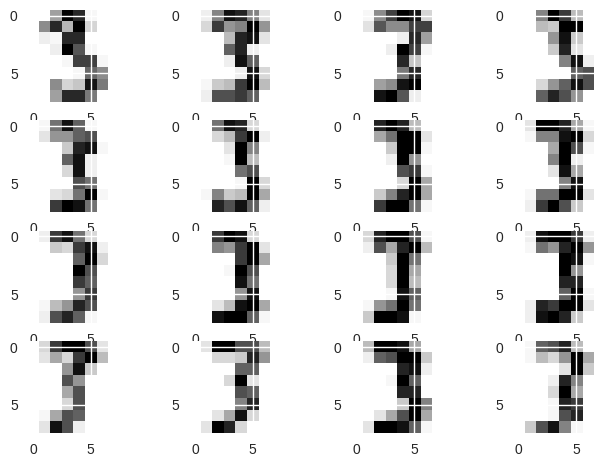

In [28]:
fig, ax = plt.subplots(4, 4)

integer_of_interest = 3
images_of_interest = digits.images[digits.target == integer_of_interest]

for i in range(4):
    for j in range(4):
        ax[i, j].imshow(images_of_interest[4*i + j])

In [30]:
pca = PCA(2)  # project from 64 to 2 dimensions
projected = pca.fit_transform(digits.data)
print(digits.data.shape)
print(projected.shape)

(1797, 64)
(1797, 2)


In [58]:
pca.explained_variance_ratio_

array([0.14890594, 0.13618771])

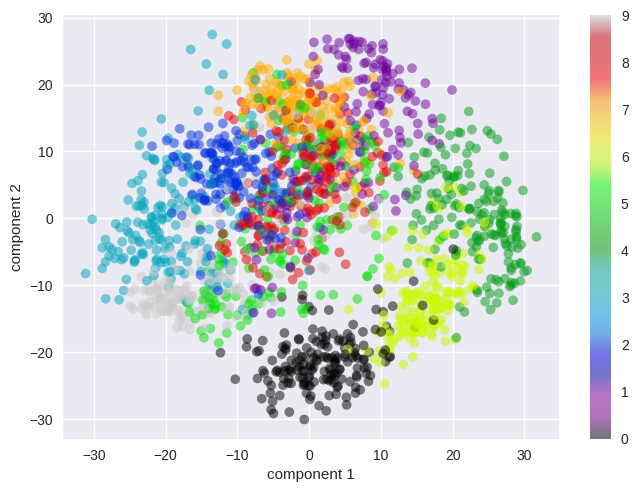

In [44]:
plt.scatter(projected[:, 0], projected[:, 1],
            c=digits.target, edgecolor='none', alpha=0.5,
            cmap=plt.colormaps.get_cmap('nipy_spectral'))
plt.xlabel('component 1')
plt.ylabel('component 2')
plt.colorbar();

## Clustering

- Another sub-problem in unsupervised learning is clustering
- In clustering, observations are grouped together according to their similarity to other observations
- The notion of similar typically depends on the *distance* between points accoring to some *metric*

### K-means

- A common clustering algorithm is called k-means clustering
- In k-means clustering
    - $k$ centroids (vectors) are chosen such that...
    - The average distance from all points to their nearest centroid is minimized
- Each observation is assigned to a single centroid
- The set of observations assigned to the same centroid is called a cluster

### Computing k-means

- In order to apply k-means to a dataset, the following happens:
    1. A number $k$ is fixed and a metric $\rho$ is chosen
    2. $k$ random vectors are proposed as centroids
    3. Repeat the following until convergence:
        1. Assign each observation to nearest current centroid
        2. Move the centroid to the mean value of all its assigned observations
- The process terminates with $k$ vectors that satisfy:
    - All observations are closest to their assigned centroid that all other centroids
    - All centroids are at the center of their assigned set of observations

We can code up the proposed algorithm by hand...

In [45]:
from sklearn import metrics


def kmeans(k, X) -> np.ndarray:
    # to get a proposal set of centroids, randomly
    # sample from rows of X
    inds = np.random.randint(0, X.shape[0], size=k)
    centroids = X[inds, :]
    while True:
        labels = metrics.pairwise_distances_argmin(X, centroids)
        new_centroids = np.array([X[labels == i].mean(axis=0) for i in range(k)])

        if np.max(np.abs(centroids - new_centroids)) < 1e-5:
            return centroids, labels

        centroids = new_centroids

### Example: made up data

- We will use `sklearn.datasets.make_blobs` to generate clusters of data
- We pick the number of samples, features, and clusters
- We'll also visualize the clusters below

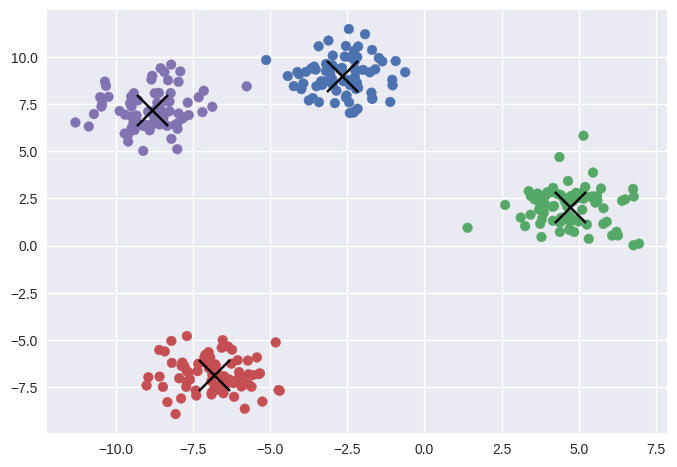

In [46]:
from sklearn import datasets

np.random.seed(42)
k_true = 4
X2, true_labels = datasets.make_blobs(n_samples=300, n_features=2, centers=k_true)
true_centers = np.array([X2[true_labels==i].mean(axis=0) for i in range(k_true)])


def plot_clusters(X, labels, centers, ax):
    ax.scatter(X2[:, 0], X2[:, 1], c=color_cycle[labels])
    ax.scatter(centers[:, 0], centers[:, 1], marker="x", c="k", s=500);
    
    
fig, ax = plt.subplots()
plot_clusters(X2, true_labels, true_centers, ax)

- Let's test our kmeans function on this dataset

In [47]:
centers, labels = kmeans(4, X2)

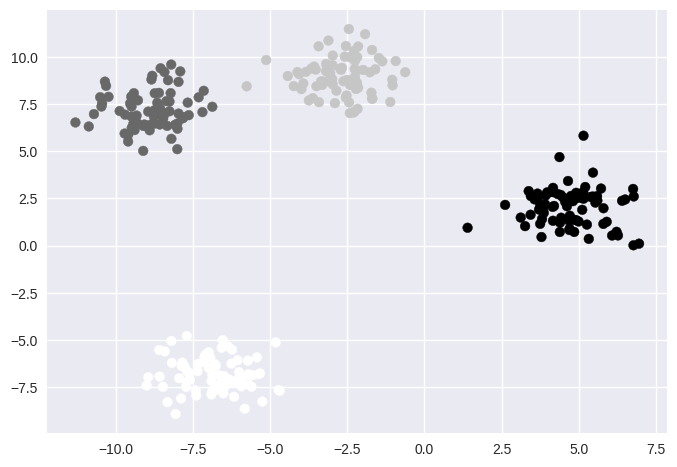

In [48]:
plt.scatter(X2[:, 0], X2[:, 1], c=labels)

In [49]:
centers

array([[-6.83235205, -6.83045748],
       [-2.70981136,  8.97143336],
       [-8.87357218,  7.17458342],
       [ 4.7182049 ,  2.04179676]])

In [50]:
true_centers

array([[-2.66914955,  8.97847783],
       [ 4.7182049 ,  2.04179676],
       [-6.83235205, -6.83045748],
       [-8.83205052,  7.19149695]])

Notice that these centroids are not in the same order, but are approximately the same:

In [51]:
centers - true_centers[[2,0,3,1], :]

array([[ 0.        ,  0.        ],
       [-0.04066181, -0.00704447],
       [-0.04152167, -0.01691353],
       [ 0.        ,  0.        ]])

We can verify that they group the points into the same clusters:

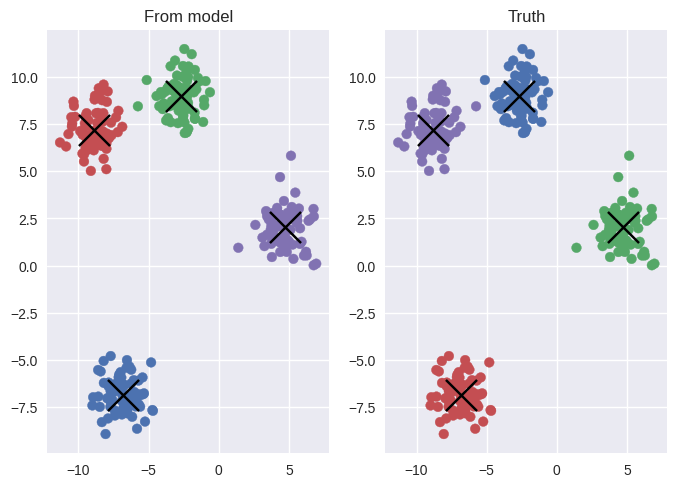

In [52]:
# plot
fig, ax = plt.subplots(1, 2)


plot_clusters(X2, labels, centers, ax[0])
plot_clusters(X2, true_labels, true_centers, ax[1])

ax[0].set_title("From model")
ax[1].set_title("Truth");

#### Notes

- The model discovered the clusters nearly perfectly (one observation was assigned to an incorrect cluster)
- We have to choose the number of clusters
    - This time we knew the "correct" answer... in practice we won't
- This dataset was simulated specifically to have clusters of points around centroids
- Kmeans can be slow for "large" data
    - Each step requires computing distance between proposed centroid and *all* observations
    - If either N or D is large, this can be costly

In [53]:
from sklearn.cluster import k_means

In [54]:
centroids, clusters, _ = k_means(projected, 10)

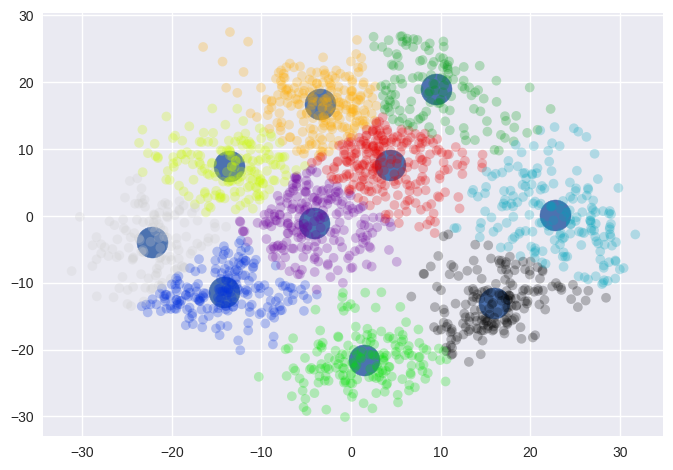

In [55]:
fig, ax = plt.subplots()

ax.scatter(centroids[:, 0], centroids[:, 1], s=500)
ax.scatter(projected[:, 0], projected[:, 1],
            c=clusters, edgecolor='none', alpha=0.25,
            cmap=plt.colormaps.get_cmap('nipy_spectral'))

In [56]:
clusters

array([5, 4, 8, ..., 8, 2, 1], shape=(1797,), dtype=int32)

In [57]:
projected

array([[ -1.25946645, -21.27488348],
       [  7.9576113 ,  20.76869896],
       [  6.99192297,   9.95598641],
       ...,
       [ 10.8012837 ,   6.96025223],
       [ -4.87210009, -12.42395362],
       [ -0.34438963,  -6.36554919]], shape=(1797, 2))

## Autoencoders

- So far we have seen two unsupervised methods:
    - **PCA**: linear dimensionality reduction via principal components
    - **K-means**: clustering observations around centroids
- Autoencoders are a neural network approach to dimensionality reduction
- Unlike PCA, they can learn **non-linear** structure in the data
- We will apply them to the MNIST handwritten digit dataset

### The Key Idea

- An autoencoder is a neural network trained to **reproduce its own input**
- It is forced to do this through a **bottleneck** — a compressed intermediate layer
- This forces the network to learn a compact representation of the data

$$x \xrightarrow{\text{encoder}} z \xrightarrow{\text{decoder}} \hat{x}$$

- $x$: original input
- $z$: latent representation (the bottleneck) — lower dimensional than $x$
- $\hat{x}$: reconstruction of the input

The network minimises the **reconstruction loss**:

$$\mathcal{L} = \|x - \hat{x}\|^2$$

No labels are needed — the target *is* the input. This makes autoencoders **self-supervised**.

### Architecture

```
Input x           Encoder              Latent z           Decoder            Output x̂
[784 pixels]  →  [Linear → ReLU] →  [32 dimensions]  →  [Linear → ReLU] →  [784 pixels]
```

- The encoder progressively compresses the input
- The decoder mirrors the encoder to reconstruct it
- The bottleneck (latent layer) is what we actually care about — it is the learned representation

### Load MNIST Data

- MNIST is a dataset of 70,000 grayscale images of handwritten digits (0–9)
- Each image is 28×28 pixels = 784 dimensions
- We will compress these 784-dimensional images into a 32-dimensional latent space

In [59]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Download MNIST  (normalise pixels to [0, 1])
transform = transforms.ToTensor()

train_data = datasets.MNIST(root="./data", train=True,  download=True, transform=transform)
test_data  = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_data, batch_size=256, shuffle=True)
test_loader  = DataLoader(test_data,  batch_size=256, shuffle=False)

print(f"Training samples : {len(train_data)}")
print(f"Test samples     : {len(test_data)}")
print(f"Image shape      : {train_data[0][0].shape}  →  {train_data[0][0].numel()} input dimensions")

Training samples : 60000
Test samples     : 10000
Image shape      : torch.Size([1, 28, 28])  →  784 input dimensions


### Visualise Some Digits

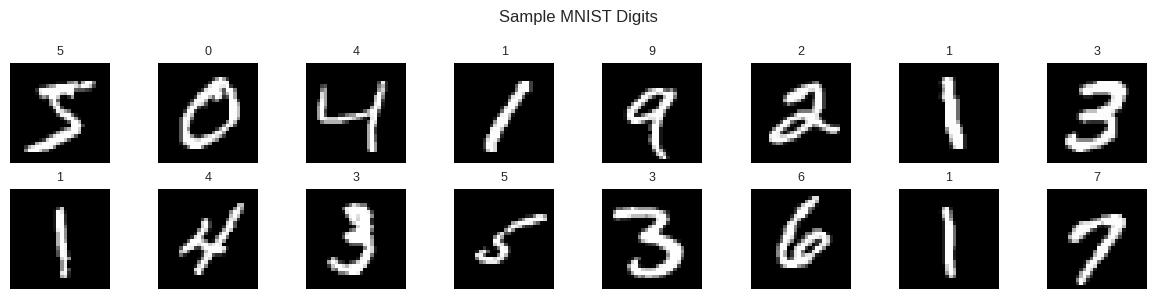

In [60]:
fig, axes = plt.subplots(2, 8, figsize=(12, 3))

for i, ax in enumerate(axes.flat):
    img, label = train_data[i]
    ax.imshow(img.squeeze(), cmap="gray")
    ax.set_title(label, fontsize=9)
    ax.axis("off")

fig.suptitle("Sample MNIST Digits", fontsize=12)
plt.tight_layout()
plt.show()

### Define the Autoencoder

We build the encoder and decoder as `nn.Sequential` stacks.
The bottleneck has 32 dimensions (vs 784 input dimensions — a **~24× compression**).

In [61]:
class Autoencoder(nn.Module):
    def __init__(self, input_dim=784, latent_dim=32):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 256), nn.ReLU(),
            nn.Linear(256, 128),       nn.ReLU(),
            nn.Linear(128, latent_dim)             # bottleneck
        )

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128), nn.ReLU(),
            nn.Linear(128, 256),        nn.ReLU(),
            nn.Linear(256, input_dim),  nn.Sigmoid()  # outputs in [0,1] to match pixel values
        )

    def forward(self, x):
        z    = self.encoder(x)
        xhat = self.decoder(z)
        return xhat, z


LATENT_DIM = 32
model = Autoencoder(latent_dim=LATENT_DIM)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

n_params = sum(p.numel() for p in model.parameters())
print(f"Input dimension  : 784")
print(f"Latent dimension : {LATENT_DIM}")
print(f"Total parameters : {n_params:,}")

Input dimension  : 784
Latent dimension : 32
Total parameters : 476,720


### Train the Autoencoder

Training loop:
1. Feed a batch of images through the autoencoder
2. Compute reconstruction loss $\|x - \hat{x}\|^2$
3. Backpropagate and update weights

No labels are used at any point.

In [62]:
EPOCHS = 10
train_losses, test_losses = [], []

for epoch in range(EPOCHS):
    # --- Training ---
    model.train()
    running_loss = 0.0
    for imgs, _ in train_loader:           # note: labels (_) are ignored
        x = imgs.view(imgs.size(0), -1)    # flatten 28×28 → 784
        xhat, _ = model(x)
        loss = criterion(xhat, x)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * len(x)
    train_losses.append(running_loss / len(train_data))

    # --- Evaluation ---
    model.eval()
    test_loss = 0.0
    with torch.no_grad():
        for imgs, _ in test_loader:
            x = imgs.view(imgs.size(0), -1)
            xhat, _ = model(x)
            test_loss += criterion(xhat, x).item() * len(x)
    test_losses.append(test_loss / len(test_data))

    print(f"Epoch {epoch+1:2d}/{EPOCHS}  |  Train loss: {train_losses[-1]:.5f}  |  Test loss: {test_losses[-1]:.5f}")

Epoch  1/10  |  Train loss: 0.06591  |  Test loss: 0.03794
Epoch  2/10  |  Train loss: 0.03091  |  Test loss: 0.02598
Epoch  3/10  |  Train loss: 0.02415  |  Test loss: 0.02186
Epoch  4/10  |  Train loss: 0.02055  |  Test loss: 0.01848
Epoch  5/10  |  Train loss: 0.01773  |  Test loss: 0.01628
Epoch  6/10  |  Train loss: 0.01587  |  Test loss: 0.01484
Epoch  7/10  |  Train loss: 0.01449  |  Test loss: 0.01352
Epoch  8/10  |  Train loss: 0.01340  |  Test loss: 0.01260
Epoch  9/10  |  Train loss: 0.01255  |  Test loss: 0.01200
Epoch 10/10  |  Train loss: 0.01186  |  Test loss: 0.01136


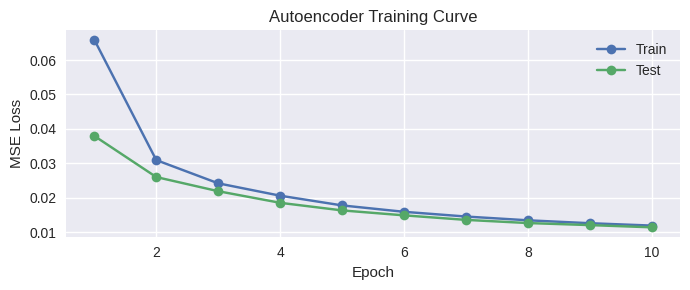

In [63]:
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(range(1, EPOCHS+1), train_losses, label="Train", marker="o")
ax.plot(range(1, EPOCHS+1), test_losses,  label="Test",  marker="o")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss")
ax.set_title("Autoencoder Training Curve")
ax.legend()
plt.tight_layout()
plt.show()

### Reconstruction Quality

- Let's compare original images to their reconstructions
- Good reconstructions mean the network has learned a useful compressed representation

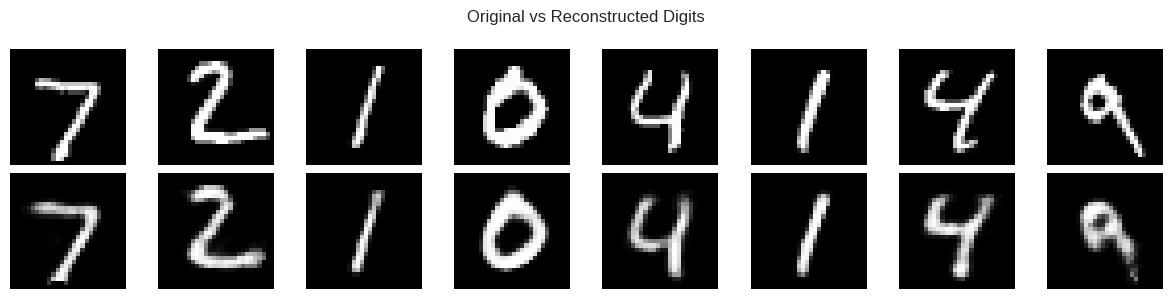

In [64]:
model.eval()

# Grab one batch from the test set
test_imgs, test_labels = next(iter(test_loader))
x_test = test_imgs.view(test_imgs.size(0), -1)

with torch.no_grad():
    x_recon, _ = model(x_test)

# Reshape back to 28×28 for plotting
originals = x_test.view(-1, 28, 28).numpy()
reconstructed = x_recon.view(-1, 28, 28).numpy()

n_show = 8
fig, axes = plt.subplots(2, n_show, figsize=(12, 3))

for i in range(n_show):
    axes[0, i].imshow(originals[i],     cmap="gray"); axes[0, i].axis("off")
    axes[1, i].imshow(reconstructed[i], cmap="gray"); axes[1, i].axis("off")

axes[0, 0].set_ylabel("Original",      fontsize=10)
axes[1, 0].set_ylabel("Reconstructed", fontsize=10)
fig.suptitle("Original vs Reconstructed Digits", fontsize=12)
plt.tight_layout()
plt.show()

### Visualising the Latent Space

- The encoder maps each 784-dimensional image to a 32-dimensional vector $z$
- We can use PCA to project $z$ down to 2 dimensions for visualisation
- If the autoencoder has learned a useful representation, digits of the same class should cluster together in latent space

In [65]:
from sklearn.decomposition import PCA

# Encode the full test set
all_z, all_labels = [], []
model.eval()
with torch.no_grad():
    for imgs, labels in test_loader:
        x = imgs.view(imgs.size(0), -1)
        _, z = model(x)
        all_z.append(z.numpy())
        all_labels.append(labels.numpy())

Z = np.concatenate(all_z)
labels = np.concatenate(all_labels)

# Project 32-d latent vectors → 2-d with PCA
pca_latent = PCA(n_components=2)
Z_2d = pca_latent.fit_transform(Z)

print(f"Latent space shape : {Z.shape}")
print(f"After PCA          : {Z_2d.shape}")
print(f"Variance explained : {pca_latent.explained_variance_ratio_.sum()*100:.1f}%")

Latent space shape : (10000, 32)
After PCA          : (10000, 2)
Variance explained : 35.7%


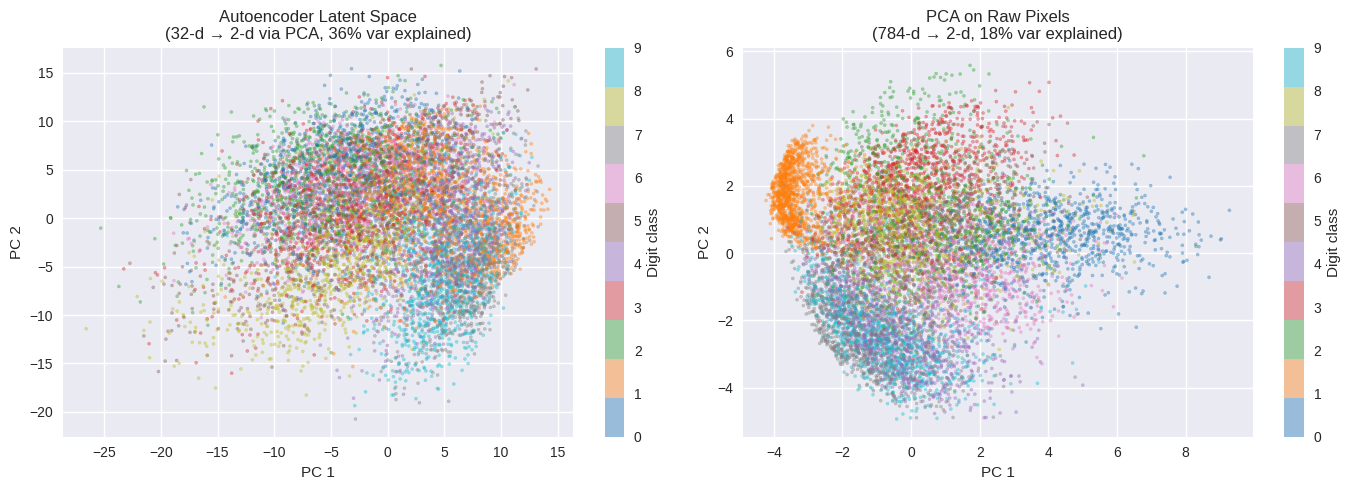

In [66]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: Autoencoder latent space ---
sc = axes[0].scatter(Z_2d[:, 0], Z_2d[:, 1],
                     c=labels, cmap="tab10", alpha=0.4, s=5)
plt.colorbar(sc, ax=axes[0], label="Digit class")
axes[0].set_title(f"Autoencoder Latent Space\n(32-d → 2-d via PCA, {pca_latent.explained_variance_ratio_.sum()*100:.0f}% var explained)")
axes[0].set_xlabel("PC 1"); axes[0].set_ylabel("PC 2")

# --- Right: PCA directly on raw pixels (for comparison) ---
pca_raw = PCA(n_components=2)
X_all = np.array([test_data[i][0].numpy().flatten() for i in range(len(test_data))])
X_2d = pca_raw.fit_transform(X_all)

sc2 = axes[1].scatter(X_2d[:, 0], X_2d[:, 1],
                      c=labels, cmap="tab10", alpha=0.4, s=5)
plt.colorbar(sc2, ax=axes[1], label="Digit class")
axes[1].set_title(f"PCA on Raw Pixels\n(784-d → 2-d, {pca_raw.explained_variance_ratio_.sum()*100:.0f}% var explained)")
axes[1].set_xlabel("PC 1"); axes[1].set_ylabel("PC 2")

plt.tight_layout()
plt.show()

### Observations

- Both methods separate the digits in 2D — but notice the cluster structure differs
- The autoencoder's latent space is richer: it captures non-linear structure, so clusters tend to be more compact and separated
- The PCA projection is linear — it can only rotate and scale the original pixel space
- This illustrates the core advantage of autoencoders over PCA: **non-linear compression**

### Summary

| | PCA | Autoencoder |
|---|---|---|
| Type of compression | Linear | Non-linear |
| Training | Eigendecomposition (closed-form) | Gradient descent (iterative) |
| Interpretability | High (variance explained is exact) | Lower |
| Scalability | Fast | Slower, needs GPU for large data |
| Flexibility | Limited | Can learn complex structure |

**When to use each:**
- Use **PCA** when you want a fast, interpretable baseline or your data has mostly linear structure
- Use an **autoencoder** when you expect non-linear relationships, or when PCA reconstructions are poor